## Setup

In [1]:
import os
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine, text
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.width', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.2f}')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 5)

load_dotenv()
url = (
    f"postgresql+psycopg2://{os.getenv('DB_USER')}:{os.getenv('DB_PASSWORD')}"
    f"@{os.getenv('DB_HOST')}:{os.getenv('DB_PORT')}/{os.getenv('DB_NAME_DWH')}"
)
engine = create_engine(url)

def q(sql: str) -> pd.DataFrame:
    with engine.connect() as conn:
        return pd.read_sql(text(sql), conn)

OUT_DIR = Path("../docs/cltv")
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

# Parámetros del CLTV
LIFESPAN_YEARS    = 3       # ventana predictiva
CHURN_THRESHOLD   = 365     # días sin comprar = churned
SNAPSHOT_DATE     = pd.Timestamp(q("SELECT MAX(sale_timestamp)::date AS d FROM dwh.fact_sales;")['d'][0])

print(f"Snapshot date (último día con datos): {SNAPSHOT_DATE.date()}")
print(f"Lifespan futuro asumido: {LIFESPAN_YEARS} años")
print(f"Umbral de churn: {CHURN_THRESHOLD} días")
print(f"BD destino: {os.getenv('DB_NAME_DWH')}")
print("Setup OK ✓")

Snapshot date (último día con datos): 2025-12-30
Lifespan futuro asumido: 3 años
Umbral de churn: 365 días
BD destino: saleshealth_dwh
Setup OK ✓


## Construir la tabla base (métricas por cliente desde fact_sales)

In [2]:
# Métricas básicas de actividad y económicas (desde fact_sales)
sql_base = """
SELECT 
    fs.customer_sk,
    dc.customer_id_nk,
    dc.full_name,
    dc.email,
    dc.cohort_year,
    dc.cohort_month,
    
    -- Volumen
    COUNT(DISTINCT fs.sale_id_nk)                        AS num_orders,
    COUNT(*)                                             AS num_items,
    SUM(fs.quantity)                                     AS total_units,
    
    -- Económicas
    ROUND(SUM(fs.gross_revenue)::numeric, 2)             AS gross_revenue,
    ROUND(SUM(fs.discount_amount)::numeric, 2)           AS discount_amount,
    ROUND(SUM(fs.net_revenue)::numeric, 2)               AS net_revenue,
    ROUND(SUM(fs.cost_amount)::numeric, 2)               AS cost_amount,
    ROUND(SUM(fs.gross_margin)::numeric, 2)              AS gross_margin,
    
    -- Temporales
    MIN(fs.sale_timestamp)::date                         AS first_order_date,
    MAX(fs.sale_timestamp)::date                         AS last_order_date
FROM dwh.fact_sales fs
JOIN dwh.dim_customer dc ON fs.customer_sk = dc.customer_sk
GROUP BY fs.customer_sk, dc.customer_id_nk, dc.full_name, dc.email, 
         dc.cohort_year, dc.cohort_month;
"""
df = q(sql_base)
print(f"Clientes con al menos 1 compra: {len(df)}")
print(f"\nPrimeras filas:")
df.head()

Clientes con al menos 1 compra: 5750

Primeras filas:


,customer_sk,customer_id_nk,full_name,email,cohort_year,cohort_month,num_orders,num_items,total_units,gross_revenue,discount_amount,net_revenue,cost_amount,gross_margin,first_order_date,last_order_date
0,1,1,Marta Ruiz García,marta.ruiz1@example.com,2018,2018-11,22,57,103,"11,740.55",8.00,"11,732.55","7,044.07","4,688.48",2020-06-29,2025-10-01
1,2,2,Alejandro López López,alejandro.lópez2@example.com,2018,2018-09,24,64,122,"12,744.26",0.00,"12,744.26","7,646.18","5,098.08",2020-03-02,2025-10-30
2,3,3,Alejandro López Álvarez,alejandro.lópez3@example.com,2019,2019-02,24,72,143,"19,862.51",0.00,"19,862.51","11,917.07","7,945.44",2020-08-17,2025-11-07
3,4,4,Javier Ruiz Fernández,javier.ruiz4@example.com,2018,2018-05,10,28,61,"8,203.76",0.00,"8,203.76","4,922.04","3,281.72",2020-04-19,2025-12-12
4,5,5,David Gómez Pérez,david.gómez5@example.com,2019,2019-12,22,54,108,"10,938.05",0.00,"10,938.05","6,562.57","4,375.48",2020-03-17,2025-12-07


## Añadir métricas derivadas

In [3]:
# Ticket medio
df['avg_order_value'] = (df['net_revenue'] / df['num_orders']).round(2)

# Lifespan en días
df['customer_lifespan_days'] = (
    pd.to_datetime(df['last_order_date']) - pd.to_datetime(df['first_order_date'])
).dt.days

# Días desde última compra (referenciado al snapshot)
df['days_since_last_order'] = (
    SNAPSHOT_DATE - pd.to_datetime(df['last_order_date'])
).dt.days

# Frecuencia anual: nº compras por año de relación
# Para clientes one-shot (lifespan=0), asumimos 1 año mínimo para no dividir por 0
df['purchase_frequency_year'] = (
    df['num_orders'] / df['customer_lifespan_days'].clip(lower=365) * 365
).round(4)

# Flags
df['is_one_shot']  = df['num_orders'] == 1
df['is_recurrent'] = df['num_orders'] >= 2
df['is_active']    = df['days_since_last_order'] <= CHURN_THRESHOLD
df['is_churned']   = df['days_since_last_order'] > CHURN_THRESHOLD

print("Distribución de flags:")
print(f"  One-shot:  {df['is_one_shot'].sum()} ({100*df['is_one_shot'].mean():.1f}%)")
print(f"  Recurrent: {df['is_recurrent'].sum()} ({100*df['is_recurrent'].mean():.1f}%)")
print(f"  Active:    {df['is_active'].sum()} ({100*df['is_active'].mean():.1f}%)")
print(f"  Churned:   {df['is_churned'].sum()} ({100*df['is_churned'].mean():.1f}%)")

print(f"\nEstadísticas de num_orders:")
print(df['num_orders'].describe())

Distribución de flags:
  One-shot:  5000 (87.0%)
  Recurrent: 750 (13.0%)
  Active:    2210 (38.4%)
  Churned:   3540 (61.6%)

Estadísticas de num_orders:
count   5,750.00
mean        3.48
std         6.59
min         1.00
25%         1.00
50%         1.00
75%         1.00
max        34.00
Name: num_orders, dtype: float64


## Añadir info de devoluciones

In [4]:
sql_returns = """
SELECT 
    fr.customer_sk,
    COUNT(*)                                       AS num_returns,
    SUM(fr.quantity_returned)                      AS units_returned,
    ROUND(SUM(fr.refund_amount)::numeric, 2)       AS refund_amount,
    ROUND(SUM(fr.margin_lost)::numeric, 2)         AS margin_lost_returns
FROM dwh.fact_returns fr
GROUP BY fr.customer_sk;
"""
df_ret = q(sql_returns)
print(f"Clientes con devoluciones: {len(df_ret)}")

# Merge con la tabla principal (LEFT para mantener clientes sin devoluciones)
df = df.merge(df_ret, on='customer_sk', how='left')

# Rellenar NaN para los que no devolvieron
for col in ['num_returns', 'units_returned', 'refund_amount', 'margin_lost_returns']:
    df[col] = df[col].fillna(0)

df['num_returns'] = df['num_returns'].astype(int)
df['units_returned'] = df['units_returned'].astype(int)

# Return rate
df['return_rate'] = (df['units_returned'] / df['total_units']).fillna(0).round(4)
df['has_returns'] = df['num_returns'] > 0

# Métricas netas
df['net_revenue_after_returns'] = (df['net_revenue'] - df['refund_amount']).round(2)
df['net_margin_after_returns']  = (df['gross_margin'] - df['margin_lost_returns']).round(2)

print(f"\nDistribución return_rate:")
print(df['return_rate'].describe())

Clientes con devoluciones: 1124

Distribución return_rate:
count   5,750.00
mean        0.07
std         0.24
min         0.00
25%         0.00
50%         0.00
75%         0.00
max         2.00
Name: return_rate, dtype: float64


## CLTV Histórico (versión A)

Estadísticas CLTV histórico:
count   5,750.00
mean      654.11
std     1,595.71
min       -72.00
25%        24.00
50%        52.00
75%       120.00
max     9,573.44
Name: cltv_historic, dtype: float64


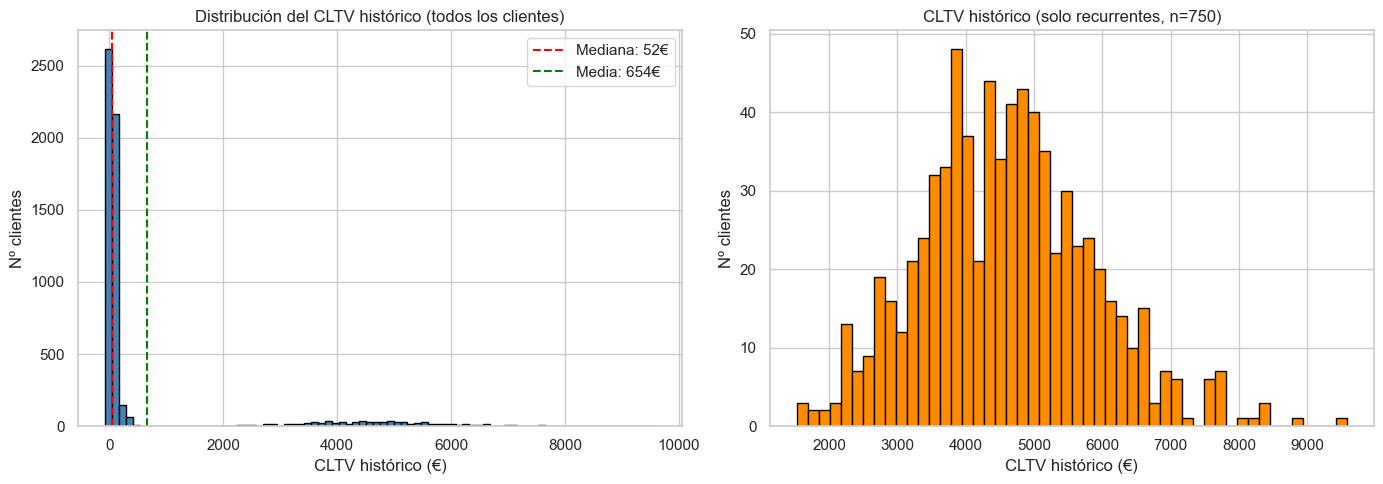

In [5]:
# CLTV histórico: el margen neto real que el cliente YA generó
df['cltv_historic'] = df['net_margin_after_returns']

print("Estadísticas CLTV histórico:")
print(df['cltv_historic'].describe())

# Distribución
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].hist(df['cltv_historic'], bins=80, edgecolor='black', color='steelblue')
ax[0].set_title('Distribución del CLTV histórico (todos los clientes)')
ax[0].set_xlabel('CLTV histórico (€)')
ax[0].set_ylabel('Nº clientes')
ax[0].axvline(df['cltv_historic'].median(), color='red', linestyle='--', 
              label=f'Mediana: {df["cltv_historic"].median():.0f}€')
ax[0].axvline(df['cltv_historic'].mean(), color='green', linestyle='--',
              label=f'Media: {df["cltv_historic"].mean():.0f}€')
ax[0].legend()

# Solo recurrentes (más interpretable)
recurrent = df[df['is_recurrent']]
ax[1].hist(recurrent['cltv_historic'], bins=50, edgecolor='black', color='darkorange')
ax[1].set_title(f'CLTV histórico (solo recurrentes, n={len(recurrent)})')
ax[1].set_xlabel('CLTV histórico (€)')
ax[1].set_ylabel('Nº clientes')

plt.tight_layout()
plt.savefig(FIG_DIR / "05_cltv_historico.png", dpi=120, bbox_inches='tight')
plt.show()

## CLTV Predictivo (versión B)

In [6]:
# CLTV predictivo: proyección a futuro
# Solo aplicable a clientes recurrentes (los one-shot no tienen comportamiento que proyectar)
# Fórmula: ticket_medio × margen% × frecuencia_anual × años_proyección

# Calculamos el margen % por cliente (puede variar según mix de productos)
df['cliente_margin_pct'] = (
    df['gross_margin'] / df['net_revenue'].replace(0, np.nan)
).fillna(0.40)  # default 40% si no hay datos

# CLTV predictivo
df['cltv_predictive'] = np.where(
    df['is_recurrent'],
    (df['avg_order_value'] * df['cliente_margin_pct'] * df['purchase_frequency_year'] * LIFESPAN_YEARS).round(2),
    0  # los one-shot no tienen CLTV predictivo
)

print(f"CLTV predictivo aplicable a {df['is_recurrent'].sum()} clientes recurrentes")
print(f"\nEstadísticas (recurrentes):")
print(df[df['is_recurrent']]['cltv_predictive'].describe())

CLTV predictivo aplicable a 750 clientes recurrentes

Estadísticas (recurrentes):
count     750.00
mean    2,635.25
std       705.39
min       908.17
25%     2,149.32
50%     2,615.19
75%     3,088.17
max     5,166.31
Name: cltv_predictive, dtype: float64


## CLTV "Fórmula del enunciado" (versión C)

In [7]:
# CLTV = Ingresos × Margen × Frecuencia × R(t)
# Interpretamos R(t) = años de vida útil restante esperada (LIFESPAN_YEARS para todos)

df['cltv_formula'] = (
    df['net_revenue'] * df['cliente_margin_pct'] * df['purchase_frequency_year'] * LIFESPAN_YEARS
).round(2)

print("Estadísticas CLTV fórmula (literal del enunciado):")
print(df['cltv_formula'].describe())

Estadísticas CLTV fórmula (literal del enunciado):
count     5,750.00
mean      7,342.95
std      20,469.46
min          24.00
25%          95.76
50%         179.88
75%         360.00
max     170,488.70
Name: cltv_formula, dtype: float64


## Comparativa de las 3 versiones

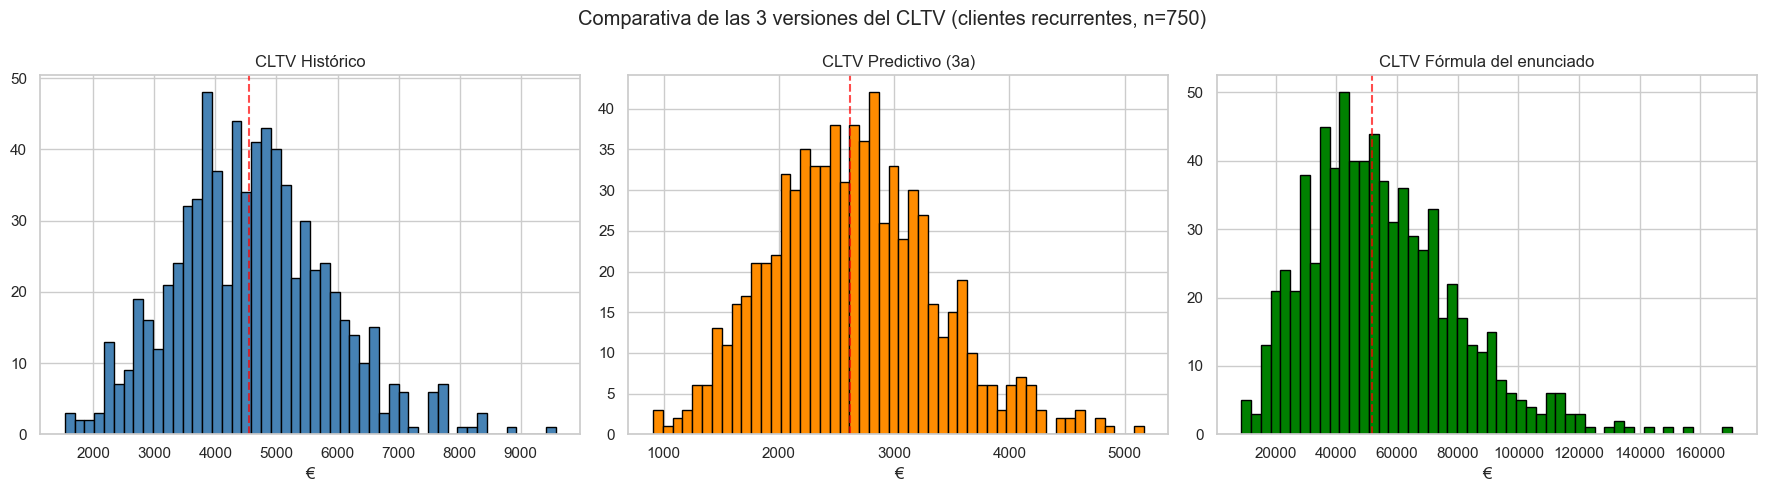


Resumen comparativo (todos los clientes):
       cltv_historic  cltv_predictive  cltv_formula
count       5,750.00         5,750.00      5,750.00
mean          654.11           343.73      7,342.95
std         1,595.71           923.38     20,469.46
min           -72.00             0.00         24.00
25%            24.00             0.00         95.76
50%            52.00             0.00        179.88
75%           120.00             0.00        360.00
max         9,573.44         5,166.31    170,488.70


In [8]:
# Comparar las 3 métricas en clientes recurrentes (para los one-shot 2 de 3 son 0)
recurrent = df[df['is_recurrent']].copy()

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for i, (col, title, color) in enumerate([
    ('cltv_historic',   'CLTV Histórico',                   'steelblue'),
    ('cltv_predictive', f'CLTV Predictivo ({LIFESPAN_YEARS}a)', 'darkorange'),
    ('cltv_formula',    'CLTV Fórmula del enunciado',       'green'),
]):
    axes[i].hist(recurrent[col], bins=50, edgecolor='black', color=color)
    axes[i].set_title(title)
    axes[i].set_xlabel('€')
    axes[i].axvline(recurrent[col].median(), color='red', linestyle='--', alpha=0.7)

plt.suptitle(f'Comparativa de las 3 versiones del CLTV (clientes recurrentes, n={len(recurrent)})')
plt.tight_layout()
plt.savefig(FIG_DIR / "06_cltv_comparativa.png", dpi=120, bbox_inches='tight')
plt.show()

# Tabla resumen
print("\nResumen comparativo (todos los clientes):")
print(df[['cltv_historic', 'cltv_predictive', 'cltv_formula']].describe().round(2))

## Pareto del CLTV histórico

Top  1% clientes (n=57) generan el 10.9% del CLTV histórico total
Top  5% clientes (n=287) generan el 44.7% del CLTV histórico total
Top 10% clientes (n=575) generan el 77.6% del CLTV histórico total
Top 20% clientes (n=1150) generan el 94.1% del CLTV histórico total


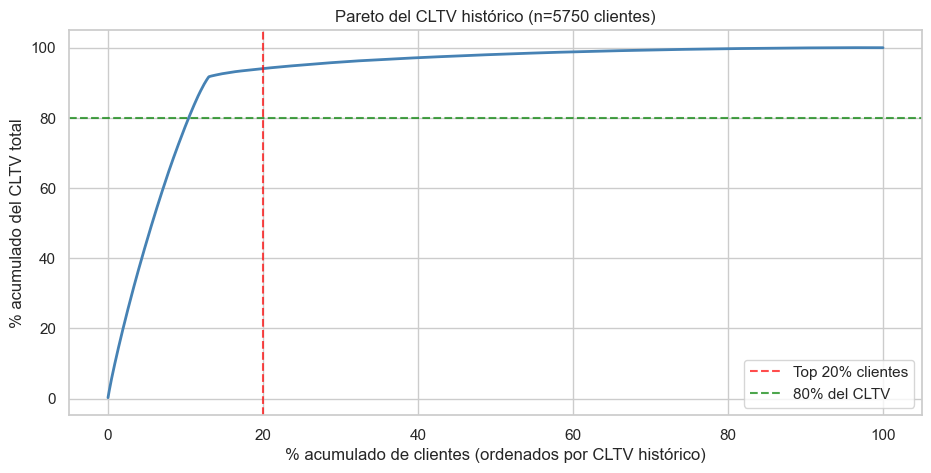

In [9]:
# Top X% de clientes generan qué % del CLTV histórico
sorted_df = df.sort_values('cltv_historic', ascending=False).reset_index(drop=True)
sorted_df['cum_cltv'] = sorted_df['cltv_historic'].cumsum()
total_cltv = sorted_df['cltv_historic'].sum()
sorted_df['pct_cum_cltv'] = sorted_df['cum_cltv'] / total_cltv * 100
sorted_df['pct_cliente'] = (sorted_df.index + 1) / len(sorted_df) * 100

# Top 1%, 5%, 10%, 20%
for pct in [1, 5, 10, 20]:
    idx = int(len(sorted_df) * pct / 100)
    top_cltv = sorted_df.iloc[idx-1]['pct_cum_cltv']
    print(f"Top {pct:>2}% clientes (n={idx}) generan el {top_cltv:.1f}% del CLTV histórico total")

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(sorted_df['pct_cliente'], sorted_df['pct_cum_cltv'], color='steelblue', linewidth=2)
ax.axvline(20, color='red', linestyle='--', alpha=0.7, label='Top 20% clientes')
ax.axhline(80, color='green', linestyle='--', alpha=0.7, label='80% del CLTV')
ax.set_xlabel('% acumulado de clientes (ordenados por CLTV histórico)')
ax.set_ylabel('% acumulado del CLTV total')
ax.set_title(f'Pareto del CLTV histórico (n={len(sorted_df)} clientes)')
ax.legend()
plt.savefig(FIG_DIR / "07_pareto_cltv.png", dpi=120, bbox_inches='tight')
plt.show()

## Top 20 clientes

In [10]:
# Top 20 clientes por CLTV histórico
top20 = df.nlargest(20, 'cltv_historic')[
    ['customer_id_nk', 'full_name', 'num_orders', 'net_revenue',
     'refund_amount', 'gross_margin', 'cltv_historic',
     'days_since_last_order', 'is_churned']
].round(2)
print("TOP 20 CLIENTES POR CLTV HISTÓRICO:")
top20

TOP 20 CLIENTES POR CLTV HISTÓRICO:


,customer_id_nk,full_name,num_orders,net_revenue,refund_amount,gross_margin,cltv_historic,days_since_last_order,is_churned
182,183,Alejandro Pérez Pérez,33,"24,922.00",989.85,"9,969.40","9,573.44",73,False
227,228,Carlos García López,30,"22,268.34",119.89,"8,907.84","8,859.88",8,False
139,140,Javier Sánchez Ruiz,28,"21,428.61",389.86,"8,571.96","8,416.00",169,False
455,456,David Díaz Díaz,31,"21,566.04",649.95,"8,621.53","8,361.53",157,False
211,212,Sergio Álvarez Martínez,34,"21,281.51",499.98,"8,513.08","8,313.08",147,False
342,343,Alejandro Fernández Pérez,30,"21,167.80",484.87,"8,467.56","8,273.60",46,False
558,559,Alejandro Pérez López,26,"21,108.81",809.87,"8,443.88","8,119.92",21,False
13,14,Ana Martínez Fernández,22,"19,501.69",0.00,"7,801.00","7,801.00",31,False
541,542,Carlos García Pérez,25,"20,042.69",549.86,"8,017.60","7,797.64",12,False
2,3,Alejandro López Álvarez,24,"19,862.51",445.95,"7,945.44","7,767.04",53,False


## Guardar resultado intermedio para el siguiente bloque

In [11]:
# Guardamos el DataFrame para poder seguir trabajando en el siguiente notebook (RFM + Churn)
df.to_pickle(OUT_DIR / "customer_metrics_base.pkl")
print(f"Guardado en {OUT_DIR / 'customer_metrics_base.pkl'}")
print(f"Filas: {len(df)}, columnas: {len(df.columns)}")

Guardado en ..\docs\cltv\customer_metrics_base.pkl
Filas: 5750, columnas: 36


## RFM Score

In [12]:
# RFM Score: Recency, Frequency, Monetary, scoring 1-5 por quintiles
# - Recency: cuánto hace de la última compra (más reciente = mejor → score 5)
# - Frequency: nº de compras (más = mejor → score 5)
# - Monetary: gasto total (más = mejor → score 5)

# Recency (invertimos: días recientes -> score alto)
df['rfm_recency'] = pd.qcut(
    df['days_since_last_order'].rank(method='first'),  # rank para evitar duplicados
    5, labels=[5, 4, 3, 2, 1]   # menos días → score 5
).astype(int)

# Frequency
df['rfm_frequency'] = pd.qcut(
    df['num_orders'].rank(method='first'),
    5, labels=[1, 2, 3, 4, 5]
).astype(int)

# Monetary (usamos net_revenue_after_returns)
df['rfm_monetary'] = pd.qcut(
    df['net_revenue_after_returns'].rank(method='first'),
    5, labels=[1, 2, 3, 4, 5]
).astype(int)

df['rfm_score'] = df['rfm_recency'] + df['rfm_frequency'] + df['rfm_monetary']

# Segmentación basada en RFM (estándar de la industria, simplificada)
def rfm_segment(row):
    r, f, m = row['rfm_recency'], row['rfm_frequency'], row['rfm_monetary']
    if r >= 4 and f >= 4 and m >= 4:
        return 'Champions'              # los mejores
    elif r >= 3 and f >= 3 and m >= 4:
        return 'Loyal Customers'        # buenos y constantes
    elif r >= 4 and f <= 2:
        return 'New Customers'          # recientes pero pocos pedidos
    elif r >= 4 and f >= 2 and m >= 2:
        return 'Potential Loyalists'    # recientes, prometedores
    elif r <= 2 and f >= 4 and m >= 4:
        return 'At Risk'                # solían ser buenos, dejaron de comprar
    elif r <= 2 and f >= 3 and m >= 3:
        return 'Cant Lose Them'         # gastaban mucho, hace tiempo no compran
    elif r <= 2 and f <= 2 and m <= 2:
        return 'Lost'                   # perdidos
    elif r <= 2 and f <= 2:
        return 'Hibernating'            # dormidos
    else:
        return 'Others'                 # casos intermedios

df['rfm_segment'] = df.apply(rfm_segment, axis=1)

# Distribución
seg_dist = df['rfm_segment'].value_counts()
print("Distribución de segmentos RFM:")
print(seg_dist)
print(f"\nTotal: {len(df)}")

Distribución de segmentos RFM:
rfm_segment
Others                 1646
New Customers           975
Champions               833
Hibernating             503
Cant Lose Them          488
Lost                    437
Loyal Customers         333
Potential Loyalists     283
At Risk                 252
Name: count, dtype: int64

Total: 5750


## Visualización RFM

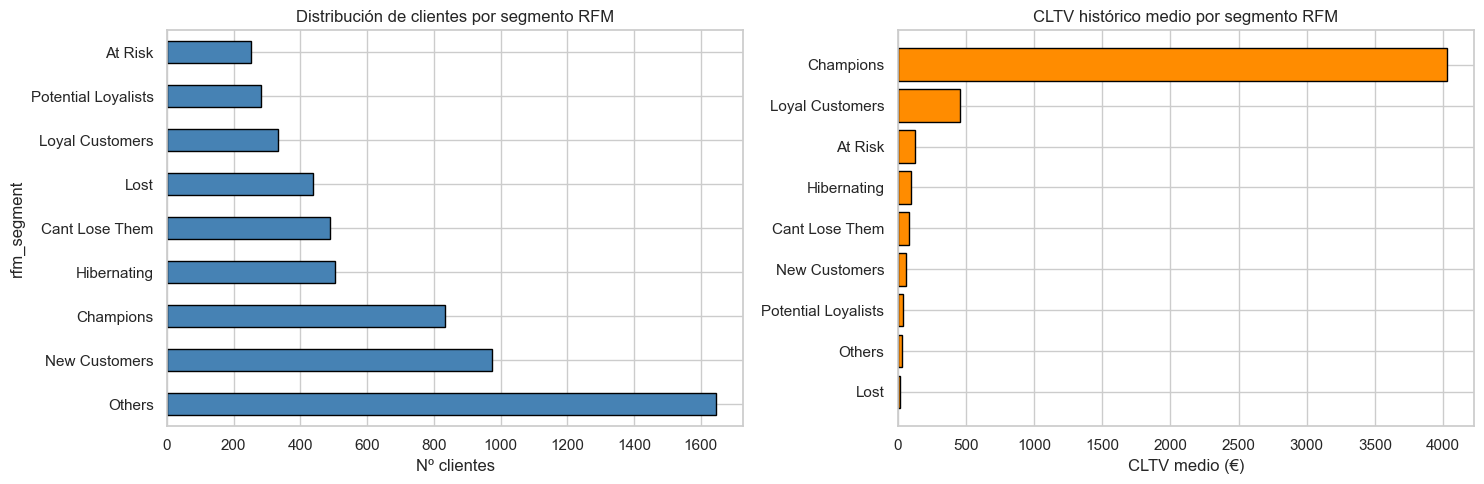


Resumen CLTV medio por segmento:
                        mean  count
rfm_segment                        
Lost                   21.00    437
Others                 30.00   1646
Potential Loyalists    41.00    283
New Customers          64.00    975
Cant Lose Them         82.00    488
Hibernating            98.00    503
At Risk               131.00    252
Loyal Customers       459.00    333
Champions           4,025.00    833


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Distribución de segmentos
seg_dist.plot(kind='barh', ax=axes[0], color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de clientes por segmento RFM')
axes[0].set_xlabel('Nº clientes')

# CLTV histórico medio por segmento
avg_cltv_seg = df.groupby('rfm_segment')['cltv_historic'].agg(['mean','count']).round(0)
avg_cltv_seg = avg_cltv_seg.sort_values('mean', ascending=True)
axes[1].barh(avg_cltv_seg.index, avg_cltv_seg['mean'], color='darkorange', edgecolor='black')
axes[1].set_title('CLTV histórico medio por segmento RFM')
axes[1].set_xlabel('CLTV medio (€)')

plt.tight_layout()
plt.savefig(FIG_DIR / "08_rfm_segmentos.png", dpi=120, bbox_inches='tight')
plt.show()

print("\nResumen CLTV medio por segmento:")
print(avg_cltv_seg)

## Churn Risk Score

In [14]:
# Churn Risk Score: probabilidad de pérdida del cliente
# Combinación de:
#   - Recency normalizada (0-1): cuanto más tiempo sin comprar, más riesgo
#   - Frequency normalizada inversa: a menos compras, más riesgo
#   - Patrón histórico: si fue cliente activo y dejó de serlo

# Componentes
recency_norm = (df['days_since_last_order'] / df['days_since_last_order'].max()).clip(0, 1)
frequency_norm_inv = 1 - (df['num_orders'] / df['num_orders'].max())

# Modelo simple: combinación ponderada
df['churn_risk_score'] = (0.7 * recency_norm + 0.3 * frequency_norm_inv).round(4)

# Niveles cualitativos
def churn_level(score):
    if score < 0.33:
        return 'Low'
    elif score < 0.66:
        return 'Medium'
    else:
        return 'High'

df['churn_risk_level'] = df['churn_risk_score'].apply(churn_level)

print("Distribución de niveles de churn risk:")
print(df['churn_risk_level'].value_counts())
print(f"\nEstadísticas churn_risk_score:")
print(df['churn_risk_score'].describe())

Distribución de niveles de churn risk:
churn_risk_level
Medium    2060
Low       1909
High      1781
Name: count, dtype: int64

Estadísticas churn_risk_score:
count   5,750.00
mean        0.53
std         0.26
min         0.03
25%         0.32
50%         0.45
75%         0.79
max         0.99
Name: churn_risk_score, dtype: float64


## Validación cruzada: churn risk vs is_churned

Cross-tab is_churned x churn_risk_level:
churn_risk_level  High   Low  Medium   All
is_churned                                
False                0  1892     318  2210
True              1781    17    1742  3540
All               1781  1909    2060  5750


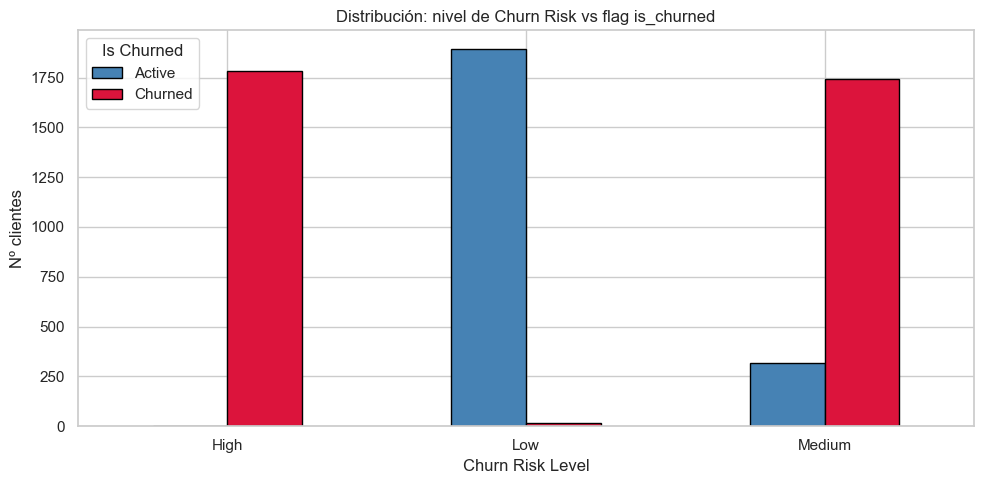

In [15]:
# Esperaríamos que los is_churned=True tengan mayoría High risk
ct = pd.crosstab(df['is_churned'], df['churn_risk_level'], margins=True)
print("Cross-tab is_churned x churn_risk_level:")
print(ct)

# Visualización
fig, ax = plt.subplots(figsize=(10, 5))
df.groupby(['churn_risk_level', 'is_churned']).size().unstack().plot(
    kind='bar', ax=ax, color=['steelblue', 'crimson'], edgecolor='black'
)
ax.set_title('Distribución: nivel de Churn Risk vs flag is_churned')
ax.set_xlabel('Churn Risk Level')
ax.set_ylabel('Nº clientes')
ax.legend(title='Is Churned', labels=['Active', 'Churned'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(FIG_DIR / "09_churn_risk.png", dpi=120, bbox_inches='tight')
plt.show()

## Resumen final por segmento (todo junto)

In [16]:
# Tabla resumen pro: por segmento RFM, agregamos métricas clave
resumen = df.groupby('rfm_segment').agg(
    n_clientes=('customer_sk', 'count'),
    cltv_hist_medio=('cltv_historic', 'mean'),
    cltv_hist_total=('cltv_historic', 'sum'),
    avg_orders=('num_orders', 'mean'),
    avg_recency=('days_since_last_order', 'mean'),
    avg_churn_score=('churn_risk_score', 'mean'),
    pct_churned=('is_churned', 'mean'),
).round(2).sort_values('cltv_hist_total', ascending=False)

resumen['pct_clientes'] = (resumen['n_clientes'] / resumen['n_clientes'].sum() * 100).round(1)
resumen['pct_cltv_total'] = (resumen['cltv_hist_total'] / resumen['cltv_hist_total'].sum() * 100).round(1)
resumen['pct_churned']    = (resumen['pct_churned'] * 100).round(1)

print("RESUMEN ESTRATÉGICO POR SEGMENTO RFM:")
print(resumen[['n_clientes', 'pct_clientes', 'cltv_hist_medio', 'cltv_hist_total', 
               'pct_cltv_total', 'avg_orders', 'avg_recency', 'pct_churned']])

RESUMEN ESTRATÉGICO POR SEGMENTO RFM:
                     n_clientes  pct_clientes  cltv_hist_medio  cltv_hist_total  pct_cltv_total  avg_orders  avg_recency  pct_churned
rfm_segment                                                                                                                          
Champions                   833         14.50         4,024.92     3,352,756.64           89.10       17.55       107.79         2.00
Loyal Customers             333          5.80           459.46       152,999.16            4.10        2.40       434.72        80.00
New Customers               975         17.00            64.24        62,636.64            1.70        1.00        62.45         1.00
Others                     1646         28.60            30.41        50,054.84            1.30        1.00       817.16        93.00
Hibernating                 503          8.70            97.52        49,053.12            1.30        1.00     1,205.35       100.00
Cant Lose Them          

## Guardar el DataFrame final preparado para insertar

In [17]:
# Sólo las columnas que existen en marts.customer_360 (en orden DDL)
cols_destino = [
    'customer_sk', 'customer_id_nk', 'full_name', 'email', 'cohort_year', 'cohort_month',
    'num_orders', 'num_items', 'total_units',
    'gross_revenue', 'discount_amount', 'net_revenue', 'cost_amount', 'gross_margin', 'avg_order_value',
    'num_returns', 'units_returned', 'refund_amount', 'margin_lost_returns', 'return_rate',
    'net_revenue_after_returns', 'net_margin_after_returns',
    'first_order_date', 'last_order_date', 'customer_lifespan_days', 'days_since_last_order',
    'purchase_frequency_year',
    'is_one_shot', 'is_recurrent', 'is_active', 'is_churned', 'has_returns',
    'cltv_historic', 'cltv_predictive', 'cltv_formula',
    'rfm_recency', 'rfm_frequency', 'rfm_monetary', 'rfm_score', 'rfm_segment',
    'churn_risk_score', 'churn_risk_level',
]

df_final = df[cols_destino].copy()
df_final.to_pickle(OUT_DIR / "customer_360_ready.pkl")
print(f"Filas listas: {len(df_final)}")
print(f"Columnas: {len(df_final.columns)}")
df_final.head()

Filas listas: 5750
Columnas: 42


,customer_sk,customer_id_nk,full_name,email,cohort_year,cohort_month,num_orders,num_items,total_units,gross_revenue,discount_amount,net_revenue,cost_amount,gross_margin,avg_order_value,num_returns,units_returned,refund_amount,margin_lost_returns,return_rate,net_revenue_after_returns,net_margin_after_returns,first_order_date,last_order_date,customer_lifespan_days,days_since_last_order,purchase_frequency_year,is_one_shot,is_recurrent,is_active,is_churned,has_returns,cltv_historic,cltv_predictive,cltv_formula,rfm_recency,rfm_frequency,rfm_monetary,rfm_score,rfm_segment,churn_risk_score,churn_risk_level
0,1,1,Marta Ruiz García,marta.ruiz1@example.com,2018,2018-11,22,57,103,"11,740.55",8.00,"11,732.55","7,044.07","4,688.48",533.30,2,2,229.89,91.96,0.02,"11,502.66","4,596.52",2020-06-29,2025-10-01,1920,90,4.18,False,True,True,False,True,"4,596.52","2,673.92","58,825.89",4,5,5,14,Champions,0.14,Low
1,2,2,Alejandro López López,alejandro.lópez2@example.com,2018,2018-09,24,64,122,"12,744.26",0.00,"12,744.26","7,646.18","5,098.08",531.01,6,6,314.67,125.88,0.05,"12,429.59","4,972.20",2020-03-02,2025-10-30,2068,61,4.24,False,True,True,False,True,"4,972.20","2,699.43","64,786.40",5,5,5,15,Champions,0.11,Low
2,3,3,Alejandro López Álvarez,alejandro.lópez3@example.com,2019,2019-02,24,72,143,"19,862.51",0.00,"19,862.51","11,917.07","7,945.44",827.60,5,5,445.95,178.40,0.04,"19,416.56","7,767.04",2020-08-17,2025-11-07,1908,53,4.59,False,True,True,False,True,"7,767.04","4,559.86","109,437.31",5,5,5,15,Champions,0.11,Low
3,4,4,Javier Ruiz Fernández,javier.ruiz4@example.com,2018,2018-05,10,28,61,"8,203.76",0.00,"8,203.76","4,922.04","3,281.72",820.38,2,2,209.98,84.00,0.03,"7,993.78","3,197.72",2020-04-19,2025-12-12,2063,18,1.77,False,True,True,False,True,"3,197.72","1,741.91","17,419.04",5,5,5,15,Champions,0.22,Low
4,5,5,David Gómez Pérez,david.gómez5@example.com,2019,2019-12,22,54,108,"10,938.05",0.00,"10,938.05","6,562.57","4,375.48",497.18,4,4,359.87,143.96,0.04,"10,578.18","4,231.52",2020-03-17,2025-12-07,2091,23,3.84,False,True,True,False,True,"4,231.52","2,291.32","50,409.47",5,5,5,15,Champions,0.11,Low
